# PAWN PVP (Piece Value Prediction) Demonstration
Loads trained model checkpoints and predicts piece values for a list of FEN strings.
- **MLP** — Simple MLP piece value predictor (12-dim, 3-layers)
- **MLP+CNN** — Enhanced MLP+CNN piece value predictor (512d, 4-layer CNN position encoder + 5-layer MLP pval predictor)

Board images are annotated with **MLP+CNN** values. Edit `FEN_STRINGS` in the last cell and run all.

In [ ]:
import torch
import numpy as np
import pandas as pd
import chess
import chess.svg
import re
from IPython.display import display, SVG
from train_all_models import ChessCNNEncoder, CNNPieceValuePredictor, SimplePieceValueMLP, PIECE_CHANNELS, fen_to_board_tensor

# Hardcoded normalisation parameters (from all_models_metrics.json)
NORM_MEAN = 2.0672445197131535
NORM_STD  = 423.68113498993176

# Sanity check: verify against Dataset TF training split parquet (rounded to 5 decimal places)
_df = pd.read_parquet('dataset-tf_train-split.parquet', columns=['piece_value'])
assert round(_df['piece_value'].mean(), 5) == round(NORM_MEAN, 5), f"NORM_MEAN mismatch: {_df['piece_value'].mean()}"
assert round(_df['piece_value'].std(),  5) == round(NORM_STD,  5), f"NORM_STD mismatch: {_df['piece_value'].std()}"
del _df

print(f'Norm params verified | NORM_MEAN={NORM_MEAN}  NORM_STD={NORM_STD}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Function to load piece value prediction (PVP) models
def load_pvp_model(cls, path, **kwargs):
    m = cls(**kwargs).to(device)
    m.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    return m.eval()

# Load MLP model
mlp      = load_pvp_model(SimplePieceValueMLP,    'dataset_tf_simple-mlp-#2.pth',                    input_dim=12, hidden_sizes=[128, 64, 32])
# Load MLP+CNN model
encoder  = load_pvp_model(ChessCNNEncoder,        'dataset_tf_512d-4layer_position-autoencoder.pth', embedding_dim=512, num_layers=4)
cnn_pval = load_pvp_model(CNNPieceValuePredictor, 'dataset_tf_mlp-pval-predictor_5-layer.pth',        embedding_dim=512, hidden_sizes=[1024, 512, 256, 128, 64], dropout_rates=[0.4, 0.3, 0.2, 0.15, 0.1])

print(f'Models loaded | device={device}')

Norm params verified | NORM_MEAN=2.0672445197131535  NORM_STD=423.68113498993176
Models loaded | device=cpu


In [64]:
PIECE_TYPES = ['p', 'P', 'n', 'N', 'b', 'B', 'r', 'R', 'q', 'Q']
_SQ = 45  # chess.svg square size

# Function to predict the piece value of each piece in a given position (excluding kings)
def predict(fen):
    board = chess.Board(fen)

    # Generate position embedding using CNN
    with torch.no_grad():
        emb = encoder(torch.from_numpy(fen_to_board_tensor(fen)).unsqueeze(0).to(device))  # (1, 512)
    rows = []

    # Predict piece value using MLP and MLP+CNN models
    with torch.no_grad():
        for sq in chess.SQUARES:
            p = board.piece_at(sq)
            
            # Skip kings and empty squares
            if p is None or p.piece_type == chess.KING:
                continue

            # Extract piece features
            sym = p.symbol()
            r, f = chess.square_rank(sq) / 7.0, chess.square_file(sq) / 7.0
            oh = np.zeros(10, dtype=np.float32)
            oh[PIECE_TYPES.index(sym)] = 1.0

            # Generate piece value predictions and save as output
            feat_mlp = torch.tensor(np.r_[oh, [r, f]],             dtype=torch.float32).unsqueeze(0).to(device)
            feat_cnn = torch.tensor(np.r_[oh, [r, f, r**2, f**2]], dtype=torch.float32).unsqueeze(0).to(device)
            rows.append({
                'piece':   sym,
                'square':  chess.square_name(sq),
                'MLP':     round(mlp(feat_mlp).item()           * NORM_STD + NORM_MEAN, 1),
                'MLP+CNN': round(cnn_pval(emb, feat_cnn).item() * NORM_STD + NORM_MEAN, 1),
            })

    return pd.DataFrame(rows)

# Function to generate an SVG of a given position (FEN string) along with piece values in the bottom-left of each occupied square
def annotate_board(fen, df, size=400):
    svg_str = chess.svg.board(chess.Board(fen), size=size)
    vb  = float(re.search(r'viewBox="0 0 (\d+(?:\.\d+)?)', svg_str).group(1))
    off = (vb - 8 * _SQ) / 2
    elems = []
    for _, row in df.iterrows():
        sq = chess.parse_square(row['square'])
        x  = off + chess.square_file(sq) * _SQ + 2.5
        y  = off + (7 - chess.square_rank(sq)) * _SQ + _SQ - 3.5
        lbl = f"{row['MLP+CNN']:.0f}"
        a   = f'x="{x:.1f}" y="{y:.1f}" font-size="10" font-family="sans-serif" font-weight="bold"'
        elems += [f'<text {a} fill="black" stroke="black" stroke-width="3">{lbl}</text>',
                  f'<text {a} fill="white">{lbl}</text>']
    return svg_str.rsplit('</svg>', 1)[0] + '\n'.join(elems) + '\n</svg>'

In [65]:
# Insert FEN strings (positions) here...
FEN_STRINGS = [
    # fig. 1, artemiev-rozum
    "r2q2kr/pp6/2pNp1n1/4Pp2/2QP2pb/4P3/PP6/2KR3R w - - 0 22", 
    # fig. 3 left, vitiguov-ganguly
    "r2qr1k1/2pn1pbp/b3p1p1/p1PpPn2/1p1P1P2/4B1P1/PP1QNNBP/2RR3K w - - 3 20", 
    # fig. 3 right, nikitenko-mittal
    "1rr3k1/3R1pb1/7p/Q4B2/5RP1/2P1q3/p1K1p2P/N3B3 b - - 2 32",  
    # fig. 5, jobova-rapport
    "r2qkb1r/pp1np1pp/2b1p3/3p4/3Q1B2/2N2N2/PPP2PPP/R3K2R b KQkq - 1 10",
    # starting position (not included in final paper)
    "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",
]

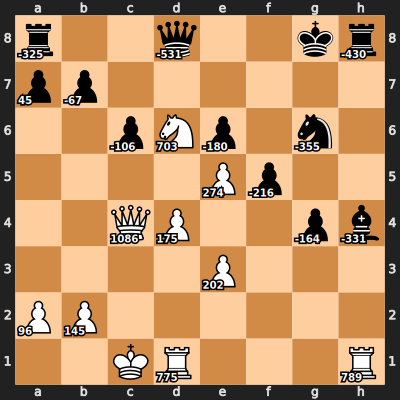

piece,square,MLP,MLP+CNN
R,d1,596.60,774.80
R,h1,561.40,788.90
P,a2,101.40,96.30
P,b2,165.50,144.90
P,e3,171.00,202.10
Q,c4,802.30,1086.10
P,d4,169.20,175.00
p,g4,-165.60,-163.70
b,h4,-502.90,-331.20
P,e5,154.10,273.90


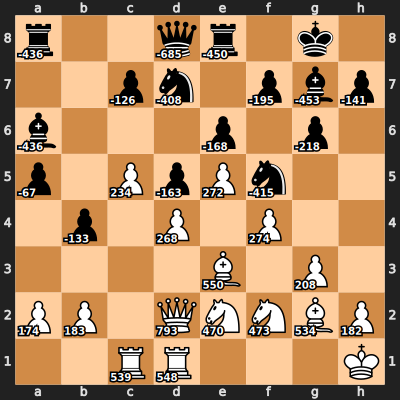

piece,square,MLP,MLP+CNN
R,c1,592.90,539.10
R,d1,596.60,547.80
P,a2,101.40,173.70
P,b2,165.50,182.90
Q,d2,783.20,793.10
N,e2,487.30,470.40
N,f2,486.00,472.70
B,g2,544.30,533.80
P,h2,94.20,181.90
B,e3,533.20,549.50


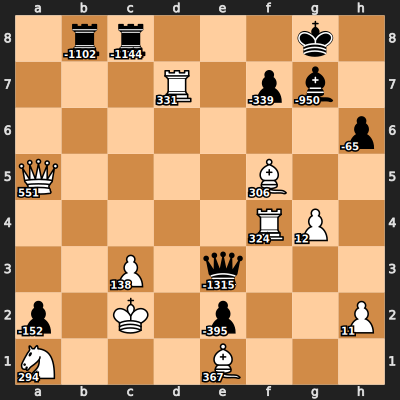

piece,square,MLP,MLP+CNN
N,a1,467.50,294.10
B,e1,522.50,366.90
p,a2,-359.80,-151.50
p,e2,-326.10,-394.80
P,h2,94.20,10.70
P,c3,165.20,137.70
q,e3,-829.70,-1315.40
R,f4,653.10,324.00
P,g4,159.70,11.80
Q,a5,785.30,551.00


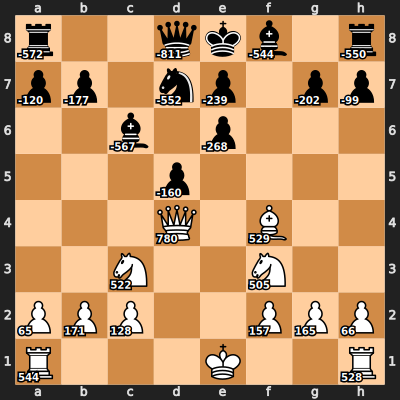

piece,square,MLP,MLP+CNN
R,a1,544.00,543.60
R,h1,561.40,528.50
P,a2,101.40,64.70
P,b2,165.50,171.10
P,c2,143.70,127.90
P,f2,177.20,157.40
P,g2,203.70,165.00
P,h2,94.20,65.90
N,c3,506.30,522.40
N,f3,503.10,505.00


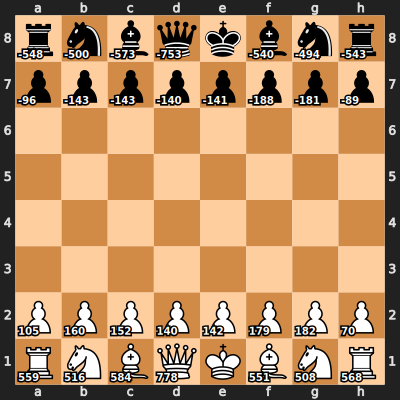

piece,square,MLP,MLP+CNN
R,a1,544.00,558.80
N,b1,483.40,516.10
B,c1,532.20,584.10
Q,d1,781.50,778.50
B,f1,519.40,550.80
N,g1,482.00,507.90
R,h1,561.40,568.30
P,a2,101.40,104.70
P,b2,165.50,159.80
P,c2,143.70,152.40


In [66]:
# Display the position (FEN) with MLP+CNN piece value prediction annotations
# Only MLP+CNN piece value predictions are included in each SVG image
# Tables display both MLP and MLP+CNN piece value predictions
for fen in FEN_STRINGS:
    df = predict(fen)
    display(SVG(annotate_board(fen, df)))
    display(df.style.hide().format({'MLP': '{:.2f}', 'MLP+CNN': '{:.2f}'}))